In [ ]:
import time
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"Đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("Không tìm thấy GPU, sử dụng CPU")

Đang sử dụng GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [89]:
# ----- Cấu hình-----
latent_dim = 100
batch_size = 256 if torch.cuda.is_available() else 64
lr = 0.0003
epochs = 300

# For MNIST (grayscale)
nc = 1  # number of channels = 1 for MNIST
ngf = 64
ndf = 32

In [90]:
# ----- Dataset -----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True,
    pin_memory=True if device.type == 'cuda' else False
)

In [91]:
# ----- Weight init -----
def init_weights(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# ----- Generator (designed for 28x28 MNIST) -----
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # We'll go: 1x1 -> 7x7 -> 14x14 -> 28x28
        self.model = nn.Sequential(
            # input: (N, latent_dim, 1, 1)
            nn.ConvTranspose2d(latent_dim, 64, kernel_size=7, stride=1, padding=0, bias=False),  # -> 7x7
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 4, kernel_size=4, stride=2, padding=1, bias=False),  # -> 14x14
            nn.BatchNorm2d(4),
            nn.ReLU(True),

            nn.ConvTranspose2d(4, nc, kernel_size=4, stride=2, padding=1, bias=False),   # -> 28x28
            nn.Tanh()  # output in [-1, 1]
        )

    def forward(self, z):
        # expect z shape (N, latent_dim) or (N, latent_dim, 1, 1)
        if z.dim() == 2:
            z = z.view(z.size(0), z.size(1), 1, 1)
        return self.model(z)

# ----- Discriminator (matching 28x28 input) -----
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # 28x28 -> 14x14 -> 7x7 -> 1x1
        self.model = nn.Sequential(
            nn.Conv2d(nc, ndf, kernel_size=4, stride=2, padding=1, bias=False),  # -> 14x14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 10, kernel_size=4, stride=2, padding=1, bias=False),  # -> 7x7
            nn.BatchNorm2d(ndf * 10),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 10, 1, kernel_size=7, stride=1, padding=0, bias=False),  # -> 1x1
            nn.Sigmoid()
        )

    def forward(self, img):
        out = self.model(img)           # (N,1,1,1)
        return out.view(img.size(0), 1) # (N,1) to match your BCELoss targets

In [92]:
# ----- Khởi tạo mô hình và tối ưu hóa -----
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

generator.apply(init_weights)
discriminator.apply(init_weights)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

In [93]:
def model_params_size_bytes(model):
    params = sum(p.numel() * p.element_size() for p in model.parameters())
    buffers = sum(b.numel() * b.element_size() for b in model.buffers())
    return params + buffers

def n_paramters_approx(n_MB: float):
    n_Bytes = int(n_MB * (1024**2))
    n_parameters = n_Bytes // 4 #Cho rằng các tham số có kiểu dữ liệu float32
    
    return int(n_parameters)

def bytes_to_mb(b):
    return b / (1024**2)

generator_parameters_size = bytes_to_mb(model_params_size_bytes(generator))
discriminator_parameters_size = bytes_to_mb(model_params_size_bytes(discriminator))
total_size = generator_parameters_size + discriminator_parameters_size
print(f"Numbers of parameters: {n_paramters_approx(total_size):,}")

print(f"Model size (MB):\n\tGenerator: {generator_parameters_size:.2f} (MB)\n\tDiscriminator: {discriminator_parameters_size:.2f} (MB)\n\tTotal: {total_size:.2f} (MB)")


Numbers of parameters: 499,350
Model size (MB):
	Generator: 1.21 (MB)
	Discriminator: 0.69 (MB)
	Total: 1.90 (MB)


In [94]:
# Storage for metrics
history = {'epoch': 0, 'loss_D': [], 'loss_G': [], 'epoch_time_sec': []}

[Epoch 1/300] Loss_D: 0.0304, Loss_G: 4.3618, Time: 26.86s


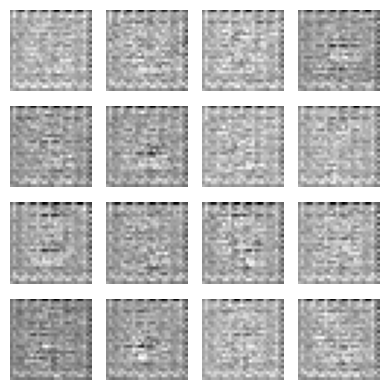

[Epoch 2/300] Loss_D: 0.0049, Loss_G: 4.9083, Time: 50.93s
[Epoch 3/300] Loss_D: 0.0008, Loss_G: 6.6352, Time: 71.49s
[Epoch 4/300] Loss_D: 0.0003, Loss_G: 7.6275, Time: 89.58s
[Epoch 5/300] Loss_D: 0.0001, Loss_G: 8.3602, Time: 110.11s
[Epoch 6/300] Loss_D: 0.0001, Loss_G: 8.7759, Time: 130.06s
[Epoch 7/300] Loss_D: 0.0001, Loss_G: 9.1471, Time: 155.34s
[Epoch 8/300] Loss_D: 0.0000, Loss_G: 9.5169, Time: 177.19s
[Epoch 9/300] Loss_D: 0.0000, Loss_G: 9.8191, Time: 196.40s
[Epoch 10/300] Loss_D: 0.0000, Loss_G: 10.0937, Time: 215.71s
[Epoch 11/300] Loss_D: 0.0000, Loss_G: 10.2870, Time: 236.63s
[Epoch 12/300] Loss_D: 0.0000, Loss_G: 10.4352, Time: 258.36s
[Epoch 13/300] Loss_D: 0.0000, Loss_G: 10.6111, Time: 277.70s
[Epoch 14/300] Loss_D: 0.0000, Loss_G: 10.8710, Time: 303.16s
[Epoch 15/300] Loss_D: 0.0000, Loss_G: 11.0935, Time: 325.17s
[Epoch 16/300] Loss_D: 0.0000, Loss_G: 11.2871, Time: 344.07s
[Epoch 17/300] Loss_D: 0.0000, Loss_G: 11.4654, Time: 364.88s
[Epoch 18/300] Loss_D: 0.00

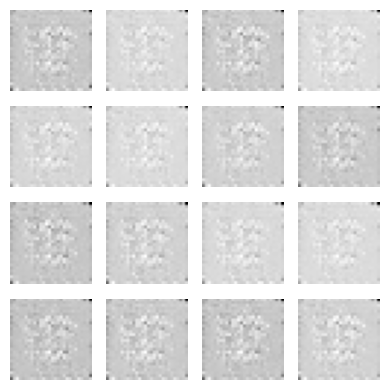

[Epoch 21/300] Loss_D: 0.0000, Loss_G: 12.0423, Time: 444.61s
[Epoch 22/300] Loss_D: 0.0000, Loss_G: 12.1888, Time: 462.76s
[Epoch 23/300] Loss_D: 0.0000, Loss_G: 12.3475, Time: 487.70s
[Epoch 24/300] Loss_D: 0.0000, Loss_G: 12.4694, Time: 509.97s
[Epoch 25/300] Loss_D: 0.0000, Loss_G: 12.5509, Time: 529.15s
[Epoch 26/300] Loss_D: 0.0000, Loss_G: 12.7012, Time: 549.89s
[Epoch 27/300] Loss_D: 0.0000, Loss_G: 12.9057, Time: 569.08s
[Epoch 28/300] Loss_D: 0.0000, Loss_G: 13.0902, Time: 587.08s
[Epoch 29/300] Loss_D: 0.0000, Loss_G: 13.2470, Time: 607.36s
[Epoch 30/300] Loss_D: 0.0000, Loss_G: 13.3822, Time: 626.47s
[Epoch 31/300] Loss_D: 0.0000, Loss_G: 13.5156, Time: 644.27s
[Epoch 32/300] Loss_D: 0.0000, Loss_G: 13.6390, Time: 662.43s
[Epoch 33/300] Loss_D: 0.0000, Loss_G: 13.7584, Time: 680.04s
[Epoch 34/300] Loss_D: 0.0259, Loss_G: 12.4615, Time: 699.15s
[Epoch 35/300] Loss_D: 0.0023, Loss_G: 7.9481, Time: 717.22s
[Epoch 36/300] Loss_D: 0.0028, Loss_G: 6.4623, Time: 763.12s
[Epoch 37/

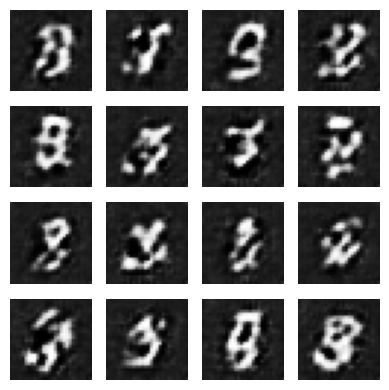

[Epoch 41/300] Loss_D: 0.0019, Loss_G: 6.7341, Time: 999.92s
[Epoch 42/300] Loss_D: 0.1765, Loss_G: 6.4731, Time: 1047.25s
[Epoch 43/300] Loss_D: 0.0192, Loss_G: 5.2125, Time: 1094.59s
[Epoch 44/300] Loss_D: 0.0205, Loss_G: 4.7782, Time: 1141.71s
[Epoch 45/300] Loss_D: 0.0152, Loss_G: 4.7934, Time: 1188.41s
[Epoch 46/300] Loss_D: 0.0135, Loss_G: 4.8475, Time: 1235.96s
[Epoch 47/300] Loss_D: 0.0131, Loss_G: 4.9158, Time: 1283.03s
[Epoch 48/300] Loss_D: 0.0144, Loss_G: 4.8986, Time: 1328.52s
[Epoch 49/300] Loss_D: 0.0194, Loss_G: 4.9388, Time: 1375.02s
[Epoch 50/300] Loss_D: 0.0184, Loss_G: 5.2041, Time: 1419.60s
[Epoch 51/300] Loss_D: 0.2290, Loss_G: 4.9546, Time: 1463.91s
[Epoch 52/300] Loss_D: 0.1021, Loss_G: 4.0391, Time: 1508.44s
[Epoch 53/300] Loss_D: 0.0529, Loss_G: 4.1097, Time: 1559.94s
[Epoch 54/300] Loss_D: 0.0328, Loss_G: 4.2846, Time: 1601.75s
[Epoch 55/300] Loss_D: 0.0295, Loss_G: 4.3862, Time: 1642.82s
[Epoch 56/300] Loss_D: 0.0277, Loss_G: 4.4598, Time: 1684.77s
[Epoch 57

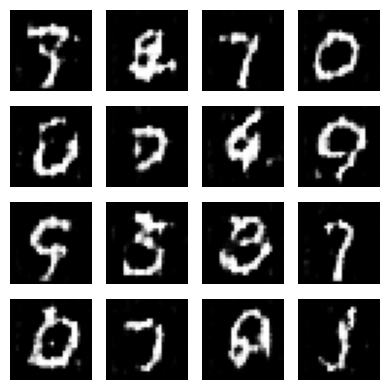

[Epoch 61/300] Loss_D: 0.0590, Loss_G: 4.2874, Time: 1933.16s
[Epoch 62/300] Loss_D: 0.0406, Loss_G: 4.2970, Time: 1987.16s
[Epoch 63/300] Loss_D: 0.0292, Loss_G: 4.4727, Time: 2042.00s
[Epoch 64/300] Loss_D: 0.0285, Loss_G: 4.5650, Time: 2096.94s
[Epoch 65/300] Loss_D: 0.0323, Loss_G: 4.6399, Time: 2145.59s
[Epoch 66/300] Loss_D: 0.0261, Loss_G: 4.7547, Time: 2199.08s
[Epoch 67/300] Loss_D: 0.7268, Loss_G: 4.7787, Time: 2251.97s
[Epoch 68/300] Loss_D: 0.1498, Loss_G: 3.7063, Time: 2302.99s
[Epoch 69/300] Loss_D: 0.1041, Loss_G: 3.8089, Time: 2357.14s
[Epoch 70/300] Loss_D: 0.1008, Loss_G: 3.5649, Time: 2412.09s
[Epoch 71/300] Loss_D: 0.0922, Loss_G: 3.8563, Time: 2463.51s
[Epoch 72/300] Loss_D: 0.0801, Loss_G: 4.0884, Time: 2513.69s
[Epoch 73/300] Loss_D: 0.0515, Loss_G: 4.1682, Time: 2563.89s
[Epoch 74/300] Loss_D: 0.0499, Loss_G: 4.4489, Time: 2615.88s
[Epoch 75/300] Loss_D: 0.0790, Loss_G: 4.5596, Time: 2665.53s
[Epoch 76/300] Loss_D: 0.0559, Loss_G: 4.3684, Time: 2716.02s
[Epoch 7

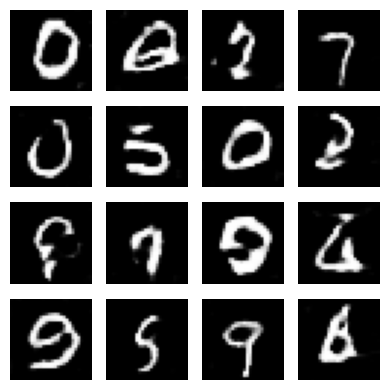

[Epoch 81/300] Loss_D: 0.0313, Loss_G: 4.9115, Time: 2973.67s
[Epoch 82/300] Loss_D: 0.0230, Loss_G: 5.0356, Time: 3011.35s
[Epoch 83/300] Loss_D: 0.0243, Loss_G: 5.1265, Time: 3054.31s
[Epoch 84/300] Loss_D: 0.0267, Loss_G: 5.2374, Time: 3106.29s
[Epoch 85/300] Loss_D: 0.0264, Loss_G: 5.3192, Time: 3154.87s
[Epoch 86/300] Loss_D: 0.1074, Loss_G: 5.3802, Time: 3205.01s
[Epoch 87/300] Loss_D: 0.0519, Loss_G: 4.6907, Time: 3254.21s
[Epoch 88/300] Loss_D: 0.0248, Loss_G: 5.0537, Time: 3303.39s
[Epoch 89/300] Loss_D: 0.0194, Loss_G: 5.2244, Time: 3354.93s
[Epoch 90/300] Loss_D: 0.0182, Loss_G: 5.3232, Time: 3405.91s
[Epoch 91/300] Loss_D: 0.0173, Loss_G: 5.4366, Time: 3455.09s
[Epoch 92/300] Loss_D: 0.0257, Loss_G: 5.5241, Time: 3482.54s
[Epoch 93/300] Loss_D: 0.0185, Loss_G: 5.5409, Time: 3504.58s
[Epoch 94/300] Loss_D: 0.0156, Loss_G: 5.5649, Time: 3525.46s
[Epoch 95/300] Loss_D: 0.0136, Loss_G: 5.6609, Time: 3543.95s
[Epoch 96/300] Loss_D: 0.0159, Loss_G: 5.7895, Time: 3561.94s
[Epoch 9

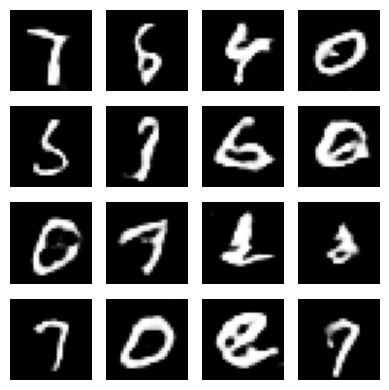

[Epoch 101/300] Loss_D: 0.0133, Loss_G: 5.7219, Time: 3655.96s
[Epoch 102/300] Loss_D: 0.0118, Loss_G: 5.8376, Time: 3675.96s
[Epoch 103/300] Loss_D: 0.0138, Loss_G: 5.9069, Time: 3694.38s
[Epoch 104/300] Loss_D: 0.1126, Loss_G: 5.8943, Time: 3712.67s
[Epoch 105/300] Loss_D: 0.0730, Loss_G: 4.5037, Time: 3731.80s
[Epoch 106/300] Loss_D: 0.0405, Loss_G: 4.8264, Time: 3759.35s
[Epoch 107/300] Loss_D: 0.0302, Loss_G: 5.0030, Time: 3784.00s
[Epoch 108/300] Loss_D: 0.0248, Loss_G: 5.1792, Time: 3809.01s
[Epoch 109/300] Loss_D: 0.0208, Loss_G: 5.3283, Time: 3841.08s
[Epoch 110/300] Loss_D: 0.0211, Loss_G: 5.4594, Time: 3865.10s
[Epoch 111/300] Loss_D: 0.0184, Loss_G: 5.6144, Time: 3888.24s
[Epoch 112/300] Loss_D: 0.0160, Loss_G: 5.8446, Time: 3913.22s
[Epoch 113/300] Loss_D: 0.0736, Loss_G: 5.5071, Time: 3935.86s
[Epoch 114/300] Loss_D: 0.0159, Loss_G: 5.7098, Time: 3958.66s
[Epoch 115/300] Loss_D: 0.0146, Loss_G: 5.8758, Time: 3977.84s
[Epoch 116/300] Loss_D: 0.0107, Loss_G: 6.0393, Time: 3

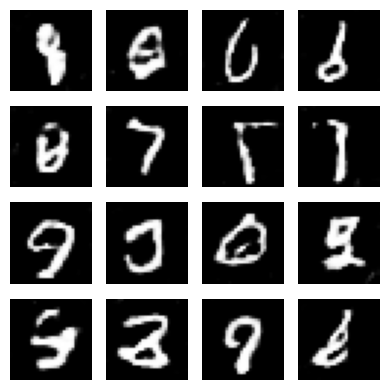

[Epoch 121/300] Loss_D: 0.0082, Loss_G: 6.5470, Time: 4102.64s
[Epoch 122/300] Loss_D: 0.0066, Loss_G: 6.6659, Time: 4126.22s
[Epoch 123/300] Loss_D: 0.0078, Loss_G: 6.6579, Time: 4151.66s
[Epoch 124/300] Loss_D: 0.0064, Loss_G: 6.7869, Time: 4176.40s
[Epoch 125/300] Loss_D: 37.0818, Loss_G: 1.8875, Time: 4200.76s
[Epoch 126/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4222.52s
[Epoch 127/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4246.35s
[Epoch 128/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4269.66s
[Epoch 129/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4291.32s
[Epoch 130/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4315.51s
[Epoch 131/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4333.71s
[Epoch 132/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4348.39s
[Epoch 133/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4363.29s
[Epoch 134/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4379.48s
[Epoch 135/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4394.64s
[Epoch 136/300] Loss_D: 50.0000, Loss_G: 0.0

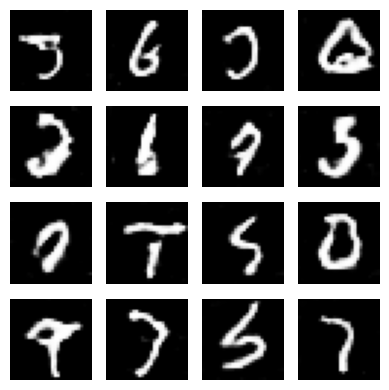

[Epoch 141/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4485.76s
[Epoch 142/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4501.47s
[Epoch 143/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4517.57s
[Epoch 144/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4533.11s
[Epoch 145/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4548.59s
[Epoch 146/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4563.19s
[Epoch 147/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4578.84s
[Epoch 148/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4595.61s
[Epoch 149/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4611.38s
[Epoch 150/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4627.00s
[Epoch 151/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4643.97s
[Epoch 152/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4659.07s
[Epoch 153/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4673.70s
[Epoch 154/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4689.62s
[Epoch 155/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4704.98s
[Epoch 156/300] Loss_D: 50.0000, Loss_G:

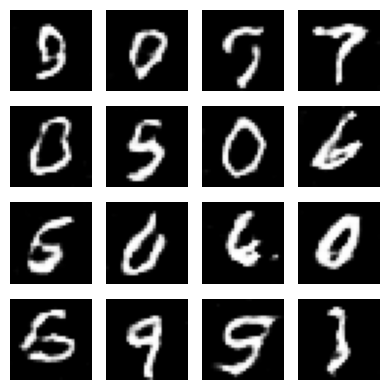

[Epoch 161/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4796.77s
[Epoch 162/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4812.05s
[Epoch 163/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4827.56s
[Epoch 164/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4843.67s
[Epoch 165/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4859.14s
[Epoch 166/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4873.98s
[Epoch 167/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4888.97s
[Epoch 168/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4906.81s
[Epoch 169/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4923.66s
[Epoch 170/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4939.14s
[Epoch 171/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4957.87s
[Epoch 172/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4975.44s
[Epoch 173/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 4992.69s
[Epoch 174/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5009.28s
[Epoch 175/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5026.20s
[Epoch 176/300] Loss_D: 50.0000, Loss_G:

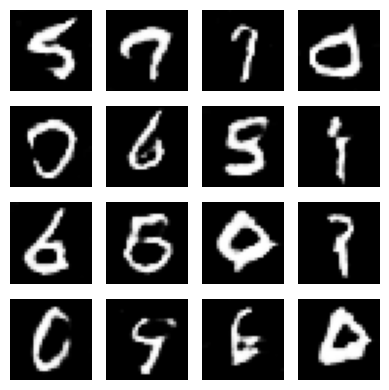

[Epoch 181/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5145.03s
[Epoch 182/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5166.60s
[Epoch 183/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5205.16s
[Epoch 184/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5226.67s
[Epoch 185/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5246.85s
[Epoch 186/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5267.23s
[Epoch 187/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5285.29s
[Epoch 188/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5303.39s
[Epoch 189/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5322.42s
[Epoch 190/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5346.94s
[Epoch 191/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5366.33s
[Epoch 192/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5387.62s
[Epoch 193/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5427.87s
[Epoch 194/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5470.36s
[Epoch 195/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5511.28s
[Epoch 196/300] Loss_D: 50.0000, Loss_G:

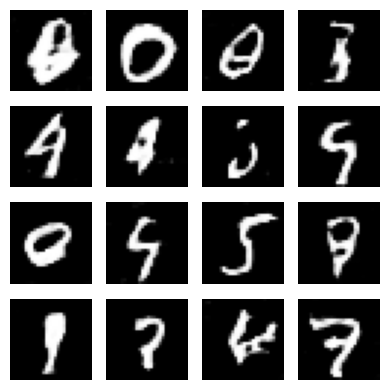

[Epoch 201/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5756.83s
[Epoch 202/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5797.88s
[Epoch 203/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5839.54s
[Epoch 204/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5879.98s
[Epoch 205/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5920.69s
[Epoch 206/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 5962.38s
[Epoch 207/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6002.24s
[Epoch 208/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6042.68s
[Epoch 209/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6083.11s
[Epoch 210/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6123.06s
[Epoch 211/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6162.86s
[Epoch 212/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6203.79s
[Epoch 213/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6243.67s
[Epoch 214/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6284.77s
[Epoch 215/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6324.64s
[Epoch 216/300] Loss_D: 50.0000, Loss_G:

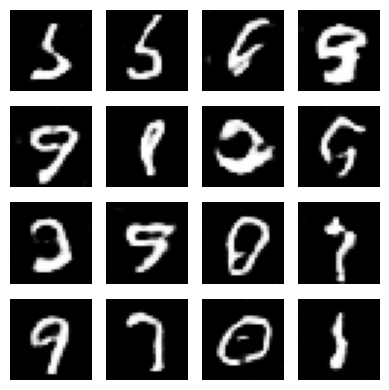

[Epoch 221/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6565.94s
[Epoch 222/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6606.38s
[Epoch 223/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6643.99s
[Epoch 224/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6686.37s
[Epoch 225/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6727.44s
[Epoch 226/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6768.81s
[Epoch 227/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6810.55s
[Epoch 228/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6851.29s
[Epoch 229/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6892.27s
[Epoch 230/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6932.54s
[Epoch 231/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 6973.01s
[Epoch 232/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7014.72s
[Epoch 233/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7055.48s
[Epoch 234/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7096.14s
[Epoch 235/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7137.60s
[Epoch 236/300] Loss_D: 50.0000, Loss_G:

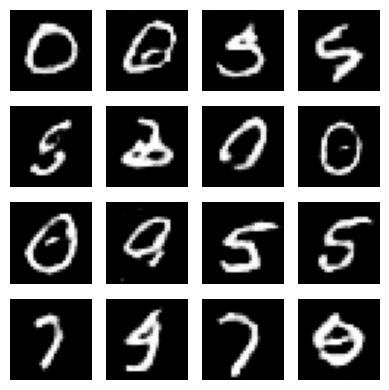

[Epoch 241/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7384.15s
[Epoch 242/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7425.60s
[Epoch 243/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7466.83s
[Epoch 244/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7508.48s
[Epoch 245/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7549.02s
[Epoch 246/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7590.13s
[Epoch 247/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7631.28s
[Epoch 248/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7672.40s
[Epoch 249/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7712.94s
[Epoch 250/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7755.12s
[Epoch 251/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7796.09s
[Epoch 252/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7837.08s
[Epoch 253/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7878.52s
[Epoch 254/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7919.30s
[Epoch 255/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 7960.86s
[Epoch 256/300] Loss_D: 50.0000, Loss_G:

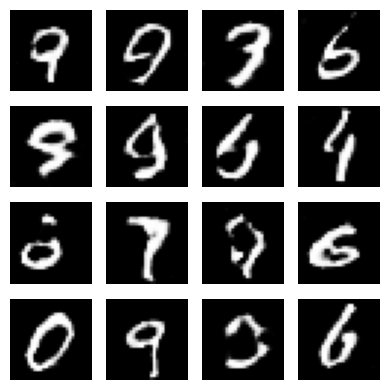

[Epoch 261/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8208.73s
[Epoch 262/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8249.76s
[Epoch 263/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8293.41s
[Epoch 264/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8311.44s
[Epoch 265/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8331.10s
[Epoch 266/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8351.11s
[Epoch 267/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8369.36s
[Epoch 268/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8388.27s
[Epoch 269/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8409.54s
[Epoch 270/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8428.35s
[Epoch 271/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8447.41s
[Epoch 272/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8464.66s
[Epoch 273/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8483.59s
[Epoch 274/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8504.23s
[Epoch 275/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8526.56s
[Epoch 276/300] Loss_D: 50.0000, Loss_G:

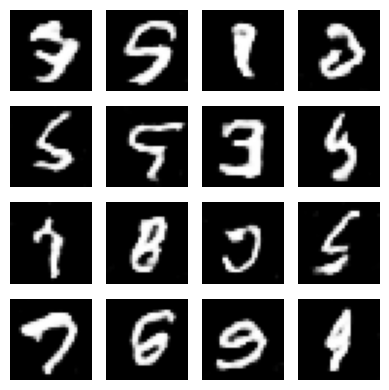

[Epoch 281/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8684.65s
[Epoch 282/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8705.07s
[Epoch 283/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8722.96s
[Epoch 284/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8739.66s
[Epoch 285/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8760.53s
[Epoch 286/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8779.42s
[Epoch 287/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8804.00s
[Epoch 288/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8827.92s
[Epoch 289/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8849.99s
[Epoch 290/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8871.60s
[Epoch 291/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8890.95s
[Epoch 292/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8911.48s
[Epoch 293/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8932.41s
[Epoch 294/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8952.84s
[Epoch 295/300] Loss_D: 50.0000, Loss_G: 0.0000, Time: 8976.52s
[Epoch 296/300] Loss_D: 50.0000, Loss_G:

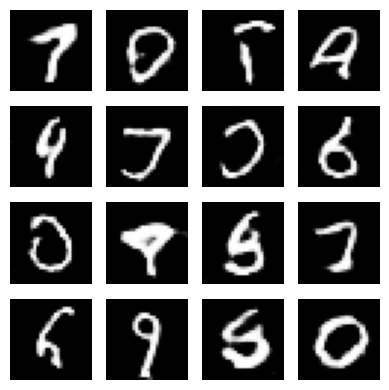

In [95]:
# ----- Training loop-----
t0 = time.perf_counter()
for epoch in range(1, epochs + 1):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0

    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device, non_blocking=True)
        b = real_imgs.size(0)

        valid = torch.ones(b, 1, device=device)
        fake = torch.zeros(b, 1, device=device)

        # -- Discriminator
        optimizer_D.zero_grad()
        loss_real = criterion(discriminator(real_imgs), valid)

        z = torch.randn(b, latent_dim, device=device)
        gen_imgs = generator(z)  # generator returns (b,1,28,28)
        loss_fake = criterion(discriminator(gen_imgs.detach()), fake)

        loss_D = 0.5 * (loss_real + loss_fake)
        loss_D.backward()
        optimizer_D.step()

        # -- Generator
        optimizer_G.zero_grad()
        loss_G = criterion(discriminator(gen_imgs), valid)
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    avg_loss_D = epoch_loss_D / len(train_loader)
    avg_loss_G = epoch_loss_G / len(train_loader)
    elapsed = time.perf_counter() - t0

    history['epoch'] += 1
    history['loss_D'].append(avg_loss_D)
    history['loss_G'].append(avg_loss_G)
    history['epoch_time_sec'].append(elapsed)

    print(f"[Epoch {epoch}/{epochs}] Loss_D: {avg_loss_D:.4f}, Loss_G: {avg_loss_G:.4f}, Time: {elapsed:.2f}s")

    if epoch % 20 == 0 or epoch == 1:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim, device=device)
            test_imgs = generator(test_z).cpu()
            fig, axes = plt.subplots(4, 4, figsize=(4, 4))
            for img, ax in zip(test_imgs, axes.flatten()):
                ax.imshow(img.squeeze() * 0.5 + 0.5, cmap='gray')
                ax.axis('off')
            plt.tight_layout()
            plt.show()

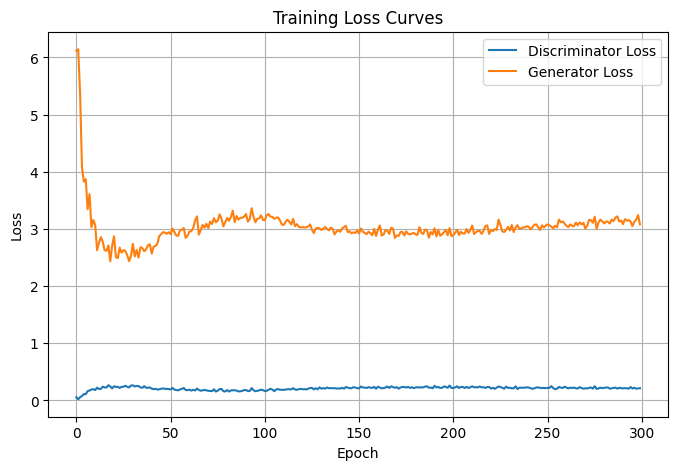

In [28]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['loss_D'], label='Discriminator Loss')
plt.plot(range(300), history['loss_G'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curves')
plt.grid(True)
plt.show()

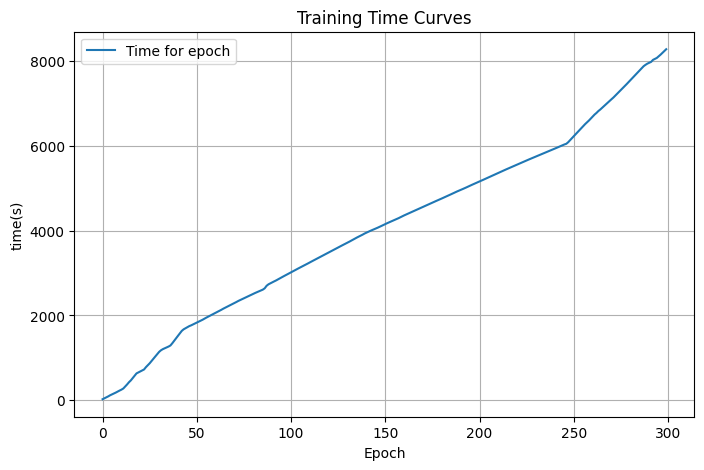

In [29]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['epoch_time_sec'], label='Time for epoch')
plt.xlabel('Epoch')
plt.ylabel('time(s)')
plt.legend()
plt.title('Training Time Curves')
plt.grid(True)
plt.show()

In [ ]:
# Export to CSV
csv_file = 'DCGAN_training_history.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['epoch', 'loss_D', 'loss_G', 'epoch_time_sec'])
    writer.writeheader()
    for e, ld, lg, t in zip(range(history['epoch']), history['loss_D'], history['loss_G'], history['epoch_time_sec']):
        writer.writerow({'epoch': e, 'loss_D': ld, 'loss_G': lg, 'epoch_time_sec': t})

print(f"Training history exported to {csv_file}")

In [ ]:
# import os
# def read_history_from_file(path, history):
#     """
#     Read training history from a CSV or JSON file and merge into `history` dict.
#     - `path`: path to CSV or JSON file (supports .csv and .json).
#     - `history`: dict expected to contain at least 'epoch' and some list fields, e.g.
#         {'epoch': 0, 'loss_D': [], 'loss_G': [], 'epoch_time_sec': []}
#     Returns updated history (same object).
#     """
#     if not os.path.isfile(path):
#         raise FileNotFoundError(f"No file at: {path}")

#     ext = os.path.splitext(path)[1].lower()
#     rows = []

#     if ext == '.csv':
#         with open(path, 'r', newline='') as f:
#             reader = csv.DictReader(f)
#             for r in reader:
#                 rows.append(r)
#     elif ext == '.json':
#         with open(path, 'r') as f:
#             data = json.load(f)
#             # Accept either list-of-rows or dict-of-lists
#             if isinstance(data, list):
#                 rows = data
#             elif isinstance(data, dict):
#                 # convert dict-of-lists to list-of-rows
#                 keys = list(data.keys())
#                 # find length
#                 length = len(data[keys[0]]) if keys else 0
#                 for i in range(length):
#                     row = {k: data[k][i] for k in keys}
#                     rows.append(row)
#             else:
#                 raise ValueError("JSON format not recognized: must be list or dict-of-lists")
#     else:
#         raise ValueError("Unsupported file extension. Use .csv or .json")

#     # Parse rows into canonical numeric values
#     parsed = []
#     for r in rows:
#         parsed_row = {}
#         for k, v in r.items():
#             if v is None or v == '':
#                 parsed_row[k] = None
#                 continue
#             # try int then float else keep string
#             try:
#                 iv = int(v)
#                 parsed_row[k] = iv
#             except Exception:
#                 try:
#                     fv = float(v)
#                     parsed_row[k] = fv
#                 except Exception:
#                     parsed_row[k] = v
#         parsed.append(parsed_row)

#     # Which epochs already in history?
#     existing_epochs = set()
#     if 'epoch' in history and isinstance(history['epoch'], int):
#         # history['epoch'] stores last epoch count, but we need epoch numbers present in lists
#         # Try to reconstruct existing epoch list length from one of the loss lists (if present).
#         # We'll treat history lists as aligned in order.
#         existing_len = None
#         for key, val in history.items():
#             if key == 'epoch': 
#                 continue
#             if isinstance(val, list):
#                 if existing_len is None or len(val) > existing_len:
#                     existing_len = len(val)
#         if existing_len is not None:
#             # assume stored epochs are 1..existing_len
#             existing_epochs = set(range(1, existing_len + 1))
#         else:
#             existing_epochs = set()

#     # Merge: determine numeric epoch column name (may be 'epoch' or 'Epoch')
#     epoch_key = None
#     if parsed:
#         possible_epoch_names = ['epoch', 'Epoch', 'iter', 'iteration', 'step']
#         for name in possible_epoch_names:
#             if name in parsed[0]:
#                 epoch_key = name
#                 break
#         # fallback to first numeric column if no 'epoch' found
#         if epoch_key is None:
#             # choose the first key whose values are ints across rows
#             for k in parsed[0].keys():
#                 if all(isinstance(row.get(k, None), int) for row in parsed):
#                     epoch_key = k
#                     break

#     if epoch_key is None:
#         raise ValueError("Couldn't find an epoch/step column in the file. Expected column named 'epoch' or similar.")

#     # Ensure history has list containers for all columns found (except epoch)
#     for k in parsed[0].keys():
#         if k == epoch_key:
#             continue
#         if k not in history:
#             history[k] = []

#     # Append only new epochs (avoid duplicates)
#     appended = 0
#     for row in parsed:
#         ep = row.get(epoch_key)
#         if ep is None:
#             continue
#         if ep in existing_epochs:
#             continue
#         # append values for each key in history (skip epoch key)
#         for k in history.keys():
#             if k == 'epoch':
#                 continue
#             history[k].append(row.get(k))
#         appended += 1
#         existing_epochs.add(ep)

#     # Update history['epoch'] to max epoch (if numeric rows exist)
#     epochs_in_file = [r.get(epoch_key) for r in parsed if isinstance(r.get(epoch_key), (int, float))]
#     if epochs_in_file:
#         # take max int
#         max_epoch = int(max(epochs_in_file))
#         if 'epoch' in history and isinstance(history['epoch'], int):
#             history['epoch'] = max(history['epoch'], max_epoch)
#         else:
#             history['epoch'] = max_epoch

#     print(f"Read {len(parsed)} rows from '{path}', appended {appended} new entries to history.")
#     return history